In [24]:
import pandas as pd
import  numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("/Users/yusenwu/Documents/GitHub/final_proj_35200/artifacts/runs/experiment_results_20251205_200938.csv")

data_for_generation = data[
    data["qa_model"].isin(["gpt-3.5-turbo", "gpt-4o", "gpt-4.1", "gpt-5-chat-latest"])
]
data_for_model_size = data[
    data["qa_model"].isin(["gpt-4.1-nano", "gpt-4.1-mini", "gpt-4.1"])
]

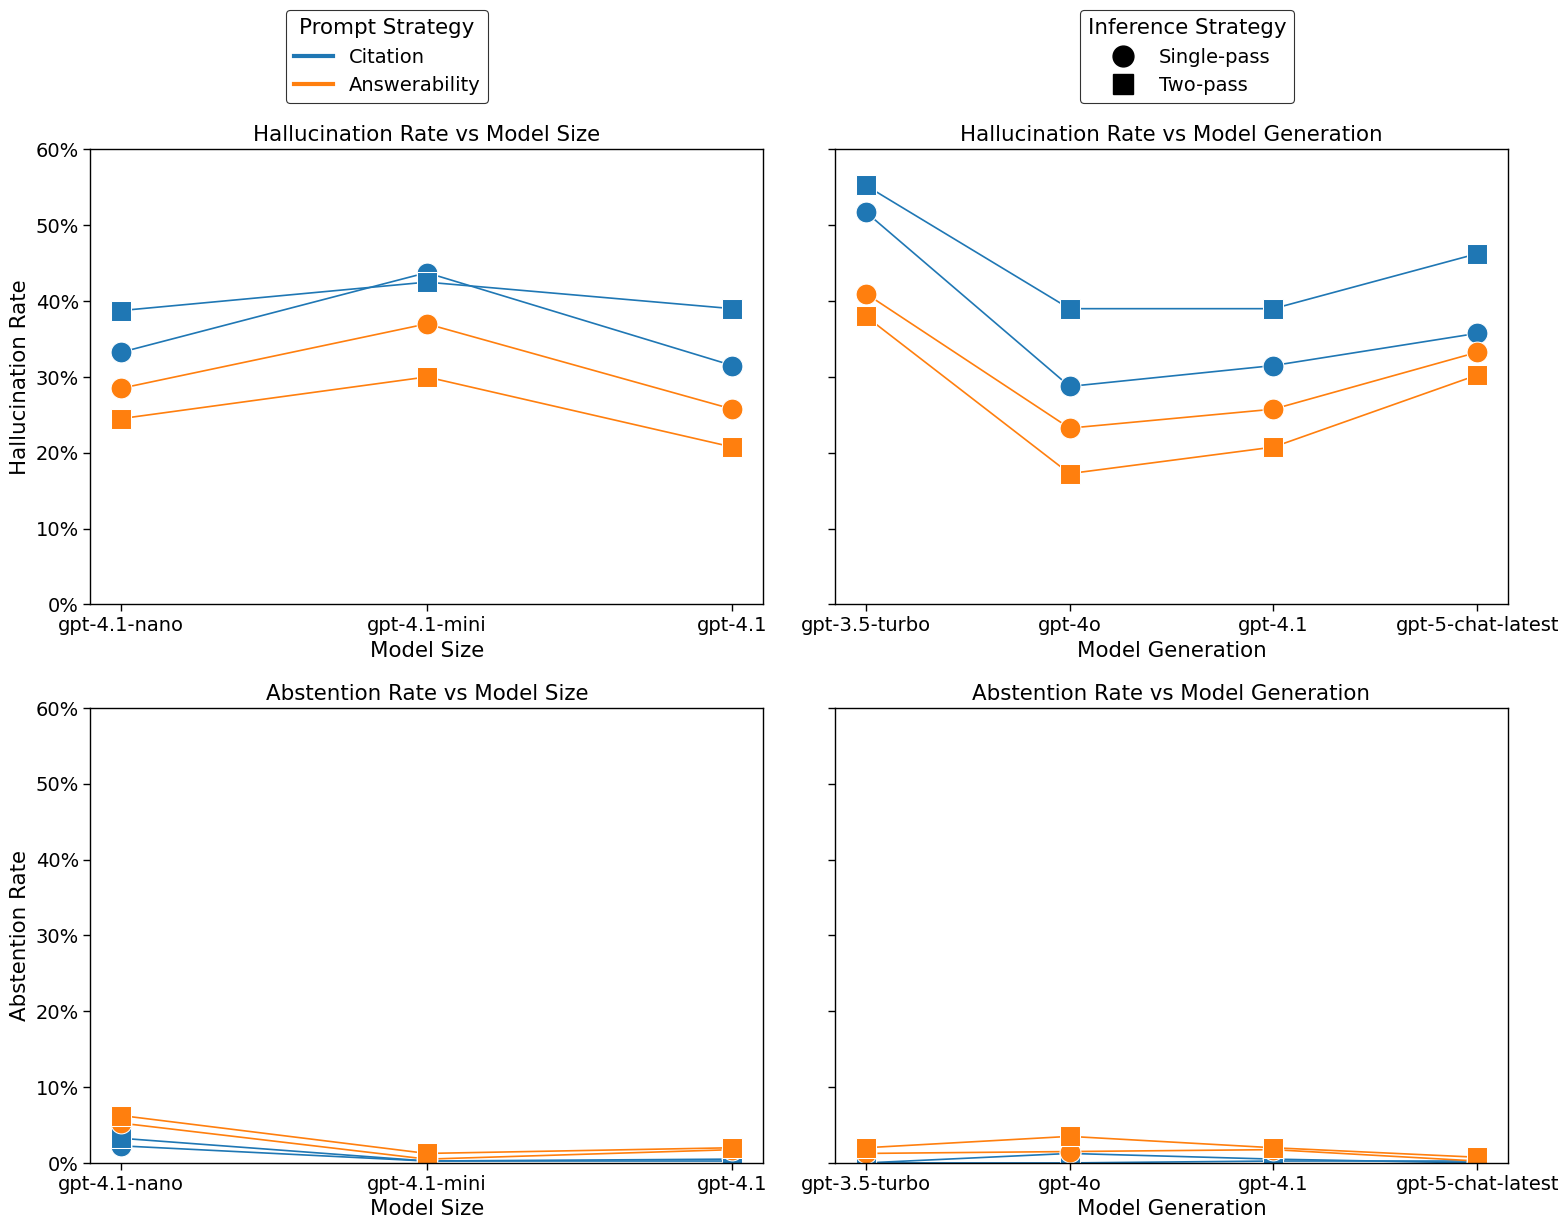

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# -------------------------------------------------------------------
# Prep data: nicer categorical labels
# -------------------------------------------------------------------
size_df = data_for_model_size.copy()
gen_df = data_for_generation.copy()

for df in [size_df, gen_df]:
    df["citation_mode"] = df["require_citations"].map({
        True: "Citation",
        False: "Answerability",
    })
    df["strategy_label"] = df["strategy"].map({
        "single": "Single-pass",
        "two_pass": "Two-pass",
    })

# -------------------------------------------------------------------
# Style maps: colors for citation mode, markers for strategy
# -------------------------------------------------------------------
palette = {
    "Citation": "C0",
    "Answerability": "C1",
}
marker_map = {
    "Single-pass": "o",
    "Two-pass": "s",
}

citation_order = ["Citation", "Answerability"]
strategy_order = ["Single-pass", "Two-pass"]

sns.set_context("paper", font_scale=1.6)

# -------------------------------------------------------------------
# Create 2x2 figure
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey="row")
(ax_size_fp, ax_gen_fp), (ax_size_fn, ax_gen_fn) = axes

# -------------------------------------------------------------------
# 1) Model Size vs False Positive Rate
# -------------------------------------------------------------------
sns.lineplot(
    data=size_df,
    x="qa_model",
    y="train_answerable_fp_rate",
    hue="citation_mode",
    style="strategy_label",
    palette=palette,
    markers=marker_map,
    dashes=False,
    markersize=15,
    hue_order=citation_order,
    style_order=strategy_order,
    ax=ax_size_fp,
)

ax_size_fp.set_title("Hallucination Rate vs Model Size")
ax_size_fp.set_xlabel("Model Size")
ax_size_fp.set_ylabel("Hallucination Rate")
ax_size_fp.legend_.remove()

# -------------------------------------------------------------------
# 2) Model Size vs False Negative Rate
# -------------------------------------------------------------------
sns.lineplot(
    data=size_df,
    x="qa_model",
    y="train_answerable_fn_rate",
    hue="citation_mode",
    style="strategy_label",
    palette=palette,
    markers=marker_map,
    dashes=False,
    markersize=15,
    hue_order=citation_order,
    style_order=strategy_order,
    ax=ax_size_fn,
)

ax_size_fn.set_title("Abstention Rate vs Model Size")
ax_size_fn.set_xlabel("Model Size")
ax_size_fn.set_ylabel("Abstention Rate")
ax_size_fn.legend_.remove()

# -------------------------------------------------------------------
# 3) Model Generation vs False Positive Rate
# -------------------------------------------------------------------
sns.lineplot(
    data=gen_df,
    x="qa_model",  # treated as generation label
    y="train_answerable_fp_rate",
    hue="citation_mode",
    style="strategy_label",
    palette=palette,
    markers=marker_map,
    dashes=False,
    markersize=15,
    hue_order=citation_order,
    style_order=strategy_order,
    ax=ax_gen_fp,
)

ax_gen_fp.set_title("Hallucination Rate vs Model Generation")
ax_gen_fp.set_xlabel("Model Generation")
ax_gen_fp.set_ylabel("Hallucination Rate")
ax_gen_fp.legend_.remove()

# -------------------------------------------------------------------
# 4) Model Generation vs False Negative Rate
# -------------------------------------------------------------------
sns.lineplot(
    data=gen_df,
    x="qa_model",
    y="train_answerable_fn_rate",
    hue="citation_mode",
    style="strategy_label",
    palette=palette,
    markers=marker_map,
    dashes=False,
    markersize=15,
    hue_order=citation_order,
    style_order=strategy_order,
    ax=ax_gen_fn,
)

ax_gen_fn.set_title("Abstention Rate vs Model Generation")
ax_gen_fn.set_xlabel("Model Generation")
ax_gen_fn.set_ylabel("Abstention Rate")
ax_gen_fn.legend_.remove()

# -------------------------------------------------------------------
# Separate legends: one for color (citations), one for shape (strategy)
# -------------------------------------------------------------------
# Legend for color (citation mode)
color_handles = [
    Line2D([0], [0], color=palette[label], lw=3)
    for label in citation_order
]
shape_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker=marker_map[label],
        linestyle="",
        markersize=15,
    )
    for label in strategy_order
]
fig.legend(color_handles, citation_order, title="Prompt Strategy",
           loc="upper center", bbox_to_anchor=(0.25, 1.035),
           frameon=True, fancybox=True, edgecolor="black")

fig.legend(shape_handles, strategy_order, title="Inference Strategy",
           loc="upper center", bbox_to_anchor=(0.75, 1.035),
           frameon=True, fancybox=True, edgecolor="black")

from matplotlib.ticker import PercentFormatter

for ax in [ax_size_fp, ax_gen_fp]:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))  # 0–1 → 0–100%
    ax.set_ylim(0, 0.6)
for ax in [ax_size_fn, ax_gen_fn]:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))  # 0–1 → 0–100%
    ax.set_ylim(0, 0.6)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("result.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

In [79]:
data.columns

Index(['experiment_name', 'qa_model', 'strategy', 'require_citations',
       'train_num_examples', 'train_retrieval_hit_rate',
       'train_citation_hit_rate', 'train_answerable_success_rate',
       'train_judge_accuracy', 'train_parse_success_rate', 'run_dir',
       'timestamp', 'retriever_backend', 'retriever_model', 'k', 'max_tokens',
       'limit', 'train_answerable_fp_rate', 'train_answerable_fn_rate'],
      dtype='object')

In [80]:
data[['qa_model', 'strategy', 'require_citations',"train_judge_accuracy"]]

,qa_model,strategy,require_citations,train_judge_accuracy
0,gpt-3.5-turbo,single,True,0.3900
1,gpt-3.5-turbo,single,False,0.4925
2,gpt-3.5-turbo,two_pass,True,0.3475
3,gpt-3.5-turbo,two_pass,False,0.5100
4,gpt-4o-mini,single,True,0.6025
5,gpt-4o-mini,single,False,0.6125
6,gpt-4o-mini,two_pass,True,0.5800
7,gpt-4o-mini,two_pass,False,0.7100
8,gpt-4o,single,True,0.6700
9,gpt-4o,single,False,0.7300


/var/folders/1d/gzmnpz4s2_s43cv7cn7wfk880000gn/T/ipykernel_92737/1521104796.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


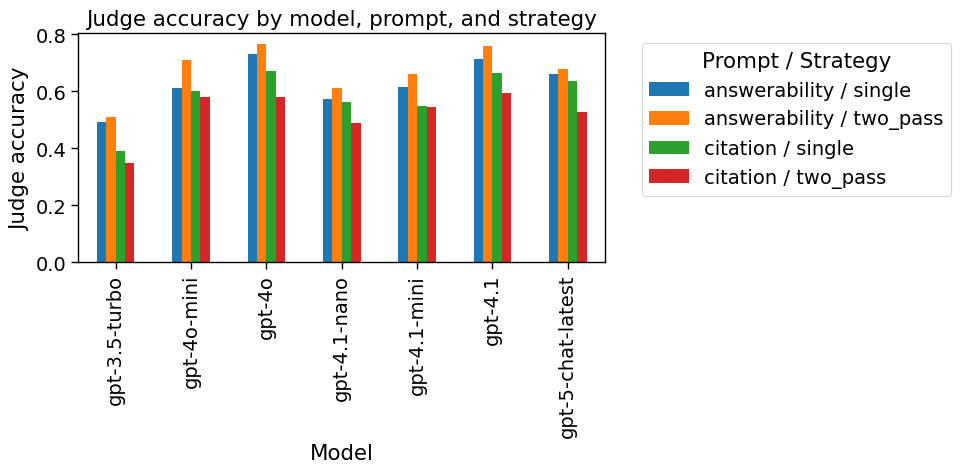

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    ("gpt-3.5-turbo", "single",   True,  0.3900),
    ("gpt-3.5-turbo", "single",   False, 0.4925),
    ("gpt-3.5-turbo", "two_pass", True,  0.3475),
    ("gpt-3.5-turbo", "two_pass", False, 0.5100),
    ("gpt-4o-mini",   "single",   True,  0.6025),
    ("gpt-4o-mini",   "single",   False, 0.6125),
    ("gpt-4o-mini",   "two_pass", True,  0.5800),
    ("gpt-4o-mini",   "two_pass", False, 0.7100),
    ("gpt-4o",        "single",   True,  0.6700),
    ("gpt-4o",        "single",   False, 0.7300),
    ("gpt-4o",        "two_pass", True,  0.5800),
    ("gpt-4o",        "two_pass", False, 0.7650),
    ("gpt-4.1-nano",  "single",   True,  0.5625),
    ("gpt-4.1-nano",  "single",   False, 0.5725),
    ("gpt-4.1-nano",  "two_pass", True,  0.4900),
    ("gpt-4.1-nano",  "two_pass", False, 0.6125),
    ("gpt-4.1-mini",  "single",   True,  0.5500),
    ("gpt-4.1-mini",  "single",   False, 0.6150),
    ("gpt-4.1-mini",  "two_pass", True,  0.5450),
    ("gpt-4.1-mini",  "two_pass", False, 0.6625),
    ("gpt-4.1",       "single",   True,  0.6650),
    ("gpt-4.1",       "single",   False, 0.7150),
    ("gpt-4.1",       "two_pass", True,  0.5925),
    ("gpt-4.1",       "two_pass", False, 0.7600),
    ("gpt-5-chat-latest", "single",   True,  0.6350),
    ("gpt-5-chat-latest", "single",   False, 0.6600),
    ("gpt-5-chat-latest", "two_pass", True,  0.5275),
    ("gpt-5-chat-latest", "two_pass", False, 0.6775),
]

df = pd.DataFrame(
    data,
    columns=["qa_model", "strategy", "require_citations", "train_judge_accuracy"],
)

# Make nicer labels
df["prompt_type"] = df["require_citations"].map({True: "citation", False: "answerability"})
df["config"] = df["prompt_type"] + " / " + df["strategy"]

# Fix model order for plotting
model_order = [
    "gpt-3.5-turbo",
    "gpt-4o-mini",
    "gpt-4o",
    "gpt-4.1-nano",
    "gpt-4.1-mini",
    "gpt-4.1",
    "gpt-5-chat-latest",
]
df["qa_model"] = pd.Categorical(df["qa_model"], categories=model_order, ordered=True)

# Pivot: rows = model, columns = config, values = judge accuracy
pivot = df.pivot_table(
    index="qa_model",
    columns="config",
    values="train_judge_accuracy",
)

# Plot grouped bars
ax = pivot.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Judge accuracy")
ax.set_xlabel("Model")
ax.set_title("Judge accuracy by model, prompt, and strategy")
ax.legend(title="Prompt / Strategy", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
